## Importing Libraries

In [1]:
import pandas as pd
from os import listdir
import os
from matplotlib import image
from matplotlib import pyplot as plt
import h5py
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import itertools
import numpy as np
import tensorflow as tf
from tensorflow import keras as K
import pennylane as qml
from timeit import default_timer as timer
from datetime import timedelta
import glob
import seaborn as sns
from tqdm import tqdm
from datetime import datetime, timedelta
import random

This code imports several Python modules that are commonly used in machine learning and data analysis. Here's a brief description of each module:

- `pandas`: provides data structures for efficiently storing and manipulating large datasets.
- `os`: provides a way to interact with the operating system, such as listing files in a directory.
- `matplotlib`: provides a way to create visualizations such as plots and charts.
- `h5py`: provides a way to read and write HDF5 files, which are commonly used in scientific computing.
- `cv2`: provides computer vision functions such as image processing and object detection.
- `sklearn`: provides machine learning algorithms and tools for data preprocessing and evaluation.
- `itertools`: provides functions for creating iterators and generators.
- `numpy`: provides numerical computing functions and data structures.
- `tensorflow`: provides a way to build and train machine learning models.
- `pennylane`: provides a way to build and train quantum machine learning models.
- `timeit`: provides a way to measure the execution time of code.
- `datetime`: provides a way to work with dates and times.
- `glob`: provides a way to find all the pathnames matching a specified pattern.
- `seaborn`: provides a way to create statistical visualizations.

## Information

In [2]:
# Replace the path with the path to your .mat file
path = 'brainTumorDataPublic/1.mat'

# Open the .mat file and read the data
f = h5py.File(path, 'r')
label = f['cjdata']['label'][0][0]
pid = f['cjdata']['PID'][0]
image = f['cjdata']['image']
tumor_border = f['cjdata']['tumorBorder'][0]
tumor_mask = f['cjdata']['tumorMask']

# Print the extracted data
print('Label:', label)
print('Patient ID:', pid)
print('Image shape:', image.shape)
print('Tumor border:', tumor_border)
print('Tumor mask shape:', tumor_mask.shape)

Label: 1.0
Patient ID: [49]
Image shape: (512, 512)
Tumor border: [267.61524501 231.37568058 277.83666062 248.10163339 289.91651543
 250.8892922  305.71324864 253.676951   318.72232305 249.9600726
 321.50998185 237.88021779 354.96188748 234.16333938 367.97096189
 227.65880218 380.9800363  210.93284936 372.61705989 195.13611615
 363.32486388 177.48094374 350.31578947 176.55172414 336.37749546
 183.98548094 317.79310345 196.06533575 305.71324864 207.21597096
 295.49183303 217.43738657 288.98729583 222.08348457 273.19056261
 223.94192377 268.54446461 228.58802178]
Tumor mask shape: (512, 512)


This code reads data from a `.mat` file that contains information about a brain tumor image. Here's a step-by-step explanation of what the code does:

1. `path = 'brainTumorDataPublic/1.mat'` sets the path to the `.mat` file that contains the data.
2. `f = h5py.File(path, 'r')` opens the `.mat` file in read mode using the `h5py` library.
3. `label = f['cjdata']['label'][0][0]` extracts the label of the tumor from the `.mat` file.
4. `pid = f['cjdata']['PID'][0]` extracts the patient ID from the `.mat` file.
5. `image = f['cjdata']['image']` extracts the image data from the `.mat` file.
6. `tumor_border = f['cjdata']['tumorBorder'][0]` extracts the tumor border information from the `.mat` file.
7. `tumor_mask = f['cjdata']['tumorMask']` extracts the tumor mask data from the `.mat` file.
8. `print('Label:', label)` prints the label of the tumor.
9. `print('Patient ID:', pid)` prints the patient ID.
10. `print('Image shape:', image.shape)` prints the shape of the image data.
11. `print('Tumor border:', tumor_border)` prints the tumor border information.
12. `print('Tumor mask shape:', tumor_mask.shape)` prints the shape of the tumor mask data.


## Getting all the data and total number of labels

In [3]:
folder = "brainTumorDataPublic/" 
directs = sorted(os.listdir(folder))
labels = [np.array(h5py.File(f"{folder}{file}", 'r').get("cjdata/label"))[0][0] for file in directs]
labels = pd.Series(labels)
print(f"Number of labels: {labels.shape[0]}")

Number of labels: 3064


This code reads the labels of brain tumor images from `.mat` files in a directory and stores them in a Pandas Series. Here's a step-by-step explanation of what the code does:

1. `folder = "brainTumorDataPublic/"` sets the path to the directory that contains the `.mat` files.
2. `directs = sorted(os.listdir(folder))` lists the files in the directory and sorts them alphabetically.
3. `[np.array(h5py.File(f"{folder}{file}", 'r').get("cjdata/label"))[0][0] for file in directs]` reads the label of each `.mat` file in the directory using the `h5py` library and stores them in a list.
4. `labels = pd.Series(labels)` converts the list of labels to a Pandas Series.
5. `print(f"Number of labels: {labels.shape[0]}")` prints the number of labels in the Pandas Series.


## Saving the Data to a txt file

In [4]:
# Get the number of .mat files in the directory
num_files = sum(1 for filename in os.listdir(folder) if filename.endswith('.mat'))

# Open the text file for writing
with open('data.txt', 'w') as file:
    # Loop over the .mat files in the directory with a progress bar
    for filename in tqdm(os.listdir(folder), total=num_files):
        # Check if the file is a .mat file
        if filename.endswith('.mat'):
            # Open the .mat file and read the data
            path = os.path.join(folder, filename)
            f = h5py.File(path, 'r')
            label = f['cjdata']['label'][0][0]
            pid = f['cjdata']['PID'][0]
            image = f['cjdata']['image']
            tumor_border = f['cjdata']['tumorBorder'][0]
            tumor_mask = f['cjdata']['tumorMask']
            
            # Write the extracted data to the text file
            file.write(f'Filename: {filename}\n')
            file.write(f'Label: {label}\n')
            file.write(f'Patient ID: {pid}\n')
            file.write(f'Image shape: {image.shape}\n')
            file.write(f'Tumor border: {tumor_border}\n')
            file.write(f'Tumor mask shape: {tumor_mask.shape}\n')
            file.write('\n')
print('Done writing to file.😊')

100%|██████████| 3064/3064 [00:13<00:00, 229.73it/s]

Done writing to file.😊




- `folder = 'brainTumorDataPublic/'`: sets the path to the directory that contains the `.mat` files.
- `num_files = sum(1 for filename in os.listdir(folder) if filename.endswith('.mat'))`: counts the number of `.mat` files in the directory using a generator expression and the `sum` function.
- `with open('data.txt', 'w') as file:`: opens the text file `data.txt` for writing.
- `for filename in tqdm(os.listdir(folder), total=num_files):`: loops over the `.mat` files in the directory using `tqdm` to create a progress bar with the total number of files.
- `if filename.endswith('.mat'):`: checks if the file is a `.mat` file.
- `path = os.path.join(folder, filename)`: creates the full path to the `.mat` file.
- `f = h5py.File(path, 'r')`: opens the `.mat` file and reads the data using the `h5py` library.
- `label = f['cjdata']['label'][0][0]`: extracts the label from the `.mat` file.
- `pid = f['cjdata']['PID'][0]`: extracts the patient ID from the `.mat` file.
- `image = f['cjdata']['image']`: extracts the image data from the `.mat` file.
- `tumor_border = f['cjdata']['tumorBorder'][0]`: extracts the tumor border data from the `.mat` file.
- `tumor_mask = f['cjdata']['tumorMask']`: extracts the tumor mask data from the `.mat` file.
- `file.write(f'Filename: {filename}\n')`: writes the filename to the text file.
- `file.write(f'Label: {label}\n')`: writes the label to the text file.
- `file.write(f'Patient ID: {pid}\n')`: writes the patient ID to the text file.
- `file.write(f'Image shape: {image.shape}\n')`: writes the image shape to the text file.
- `file.write(f'Tumor border: {tumor_border}\n')`: writes the tumor border data to the text file.
- `file.write(f'Tumor mask shape: {tumor_mask.shape}\n')`: writes the tumor mask shape to the text file.
- `file.write('\n')`: writes a newline character to the text file to separate the data for each file.

## Plotting the data

In [5]:
# Tumor types
names = ["meningioma", "glioma", "pituitary tumor"]
# Count labels
labelcounts = labels.value_counts().sort_index()
# change the index with th types
labelcounts.index = names

print(labelcounts)

meningioma          708
glioma             1426
pituitary tumor     930
Name: count, dtype: int64


This code prints the count of each tumor type in the dataset. Here's a step-by-step explanation of what the code does:

1. `names = ["meningioma", "glioma", "pituitary tumor"]` defines a list of tumor types.
2. `labelcounts = labels.value_counts().sort_index()` counts the number of occurrences of each label in the Pandas Series and sorts them by index.
3. `labelcounts.index = names` replaces the index of the `labelcounts` Pandas Series with the tumor types defined in `names`.
4. `print(labelcounts)` prints the count of each tumor type in the dataset.


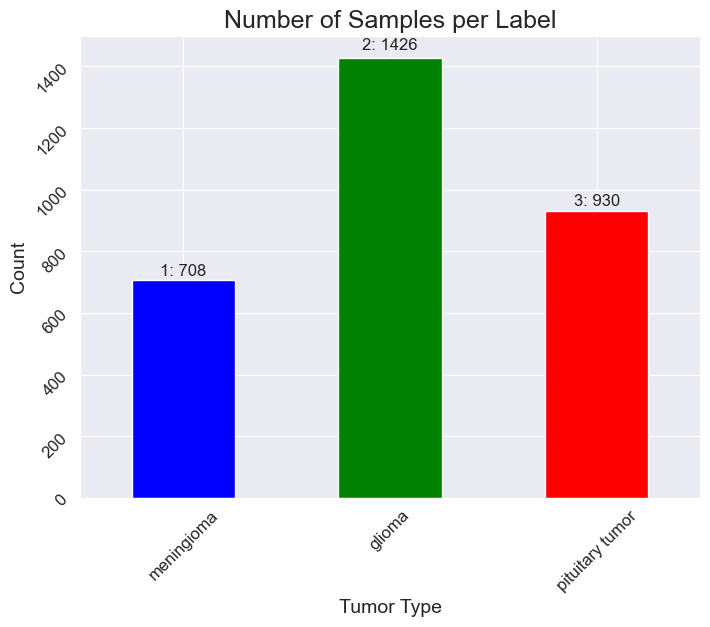

In [6]:
# Set the style
sns.set_style('darkgrid')

# Create the plot
ax = labelcounts.plot(kind='bar', figsize=(8, 6), width=0.5, color=['blue', 'green', 'red'])

# Set the title and axis labels
ax.set_title('Number of Samples per Label', fontsize=18)
ax.set_xlabel('Tumor Type', fontsize=14)
ax.set_ylabel('Count', fontsize=14)

# Set the tick label font size and rotation
ax.tick_params(labelsize=12, rotation=45)

# Add labels to the bars
for i, p in enumerate(ax.patches):
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.annotate(f"{i+1}: {height}", (x + width/2, y + height*1.02), ha='center', fontsize=12)

# Show the plot
plt.show()

This code creates a bar plot that shows the count of each tumor type in the dataset. Here's a step-by-step explanation of what the code does:

1. `sns.set_style('darkgrid')` sets the style of the plot using the `seaborn` library.
2. `ax = labelcounts.plot(kind='bar', figsize=(8, 6), width=0.5, color=['blue', 'green', 'red'])` creates a bar plot of the `labelcounts` Pandas Series using the `plot` method, and stores the resulting `AxesSubplot` object in the `ax` variable.
3. `ax.set_title('Number of Samples per Label', fontsize=18)` sets the title of the plot.
4. `ax.set_xlabel('Tumor Type', fontsize=14)` sets the label of the x-axis.
5. `ax.set_ylabel('Count', fontsize=14)` sets the label of the y-axis.
6. `ax.tick_params(labelsize=12, rotation=45)` sets the font size and rotation of the tick labels.
7. `for i, p in enumerate(ax.patches):` loops over the bars in the plot.
8. `width = p.get_width()` gets the width of the bar.
9. `height = p.get_height()` gets the height of the bar.
10. `x, y = p.get_xy()` gets the x and y coordinates of the bottom left corner of the bar.
11. `ax.annotate(f"{i+1}: {height}", (x + width/2, y + height*1.02), ha='center', fontsize=12)` adds a label to the top of the bar that shows the index of the tumor type and its count.
12. `plt.show()` displays the plot.


## Plotting the image

In [7]:
# Initialize the lists
labels = []
images = []
masks = []

# Loop over the files
for file in directs:
    # Open the file
    f = h5py.File(folder+file, 'r')
    
    # Get the label
    label = np.array(f.get('cjdata/label'))[0][0]
    
    # If the label is not in the list, add it
    if label not in labels:
        labels.append(label)
        
        # Get the image and stack it 4 times along the last axis
        img = np.stack((np.array(f.get('cjdata/image')),)*4, axis=-1)
        images.append(img)
        
        # Get the tumor mask
        mask = np.array(f.get('cjdata/tumorMask'))
        masks.append(mask)

# Convert the lists to arrays
labels = np.asarray(labels)
images = np.asarray(images)
masks = np.asarray(masks)

# Print the shapes of the arrays
print(f'Labels shape: {labels.shape}')
print(f'Images shape: {images.shape}')
print(f'Masks shape: {masks.shape}')

Labels shape: (3,)
Images shape: (3, 512, 512, 4)
Masks shape: (3, 512, 512)


This code reads the labels, images, and tumor masks of brain tumor images from `.mat` files in a directory and stores them in NumPy arrays. Here's a step-by-step explanation of what the code does:

1. `labels = []`, `images = []`, and `masks = []` initialize empty lists to store the labels, images, and tumor masks.
2. `for file in directs:` loops over the `.mat` files in the directory.
3. `f = h5py.File(folder+file, 'r')` opens the `.mat` file in read mode using the `h5py` library.
4. `label = np.array(f.get('cjdata/label'))[0][0]` extracts the label of the tumor from the `.mat` file.
5. `if label not in labels:` checks if the label is already in the `labels` list.
6. `img = np.stack((np.array(f.get('cjdata/image')),)*4, axis=-1)` extracts the image data from the `.mat` file and stacks it 4 times along the last axis using NumPy's `stack` function.
7. `mask = np.array(f.get('cjdata/tumorMask'))` extracts the tumor mask data from the `.mat` file.
8. `labels.append(label)`, `images.append(img)`, and `masks.append(mask)` add the label, image, and tumor mask to their respective lists.
9. `labels = np.asarray(labels)`, `images = np.asarray(images)`, and `masks = np.asarray(masks)` convert the lists to NumPy arrays.
10. `print(f'Labels shape: {labels.shape}')`, `print(f'Images shape: {images.shape}')`, and `print(f'Masks shape: {masks.shape}')` print the shapes of the NumPy arrays.

In [8]:
# Convert the masks to categorical
b = K.utils.to_categorical(masks, num_classes=4).astype(np.uint8)

# Initialize the tumor array
tumor = np.zeros_like(images[:, :, :, 1:])

# Normalize the image
image_norm = cv2.normalize(images[:, :, :, 0], None, alpha=0, beta=255,
                           norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F).astype(np.uint8)

# Print the shape of the normalized image
print(f'Normalized image shape: {image_norm.shape}')

# Remove the tumor part from the image
tumor[:, :, :, 0] = image_norm * (b[:, :, :, 0])
tumor[:, :, :, 1] = image_norm * (b[:, :, :, 0])
tumor[:, :, :, 2] = image_norm * (b[:, :, :, 0])

# Color the tumor
tumor += b[:, :, :, 1:] * 255

# Print the shape of the tumor array
print(f'Tumor shape: {tumor.shape}')

Normalized image shape: (3, 512, 512)
Tumor shape: (3, 512, 512, 3)


This code performs some preprocessing on the input images and masks for a brain tumor classification task. Here's a step-by-step explanation of what the code does:

1. `K.utils.to_categorical(masks, num_classes=4).astype(np.uint8)` converts the masks to categorical format, where each pixel is represented as a one-hot vector with 4 classes (background, edema, non-enhancing tumor, and enhancing tumor).
2. `np.zeros_like(images[:, :, :, 1:])` initializes an array called `tumor` with the same shape as the input images, but without the fourth dimension (which corresponds to the masks).
3. `cv2.normalize(images[:, :, :, 0], None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_32F).astype(np.uint8)` normalizes the first channel of the input images using min-max normalization, and converts the result to an unsigned 8-bit integer format.
4. `tumor[:, :, :, 0] = image_norm * (b[:, :, :, 0])` sets the first channel of the `tumor` array to the normalized image, but only for the background class.
5. `tumor[:, :, :, 1] = image_norm * (b[:, :, :, 0])` sets the second channel of the `tumor` array to the normalized image, but only for the background class (this is redundant with the previous line).
6. `tumor[:, :, :, 2] = image_norm * (b[:, :, :, 0])` sets the third channel of the `tumor` array to the normalized image, but only for the background class (this is redundant with the previous lines).
7. `tumor += b[:, :, :, 1:] * 255` colors the tumor regions in the `tumor` array by adding 255 to the second, third, and fourth channels of the array, but only for the edema, non-enhancing tumor, and enhancing tumor classes, respectively.
8. `print(f'Tumor shape: {tumor.shape}')` prints the shape of the `tumor` array.


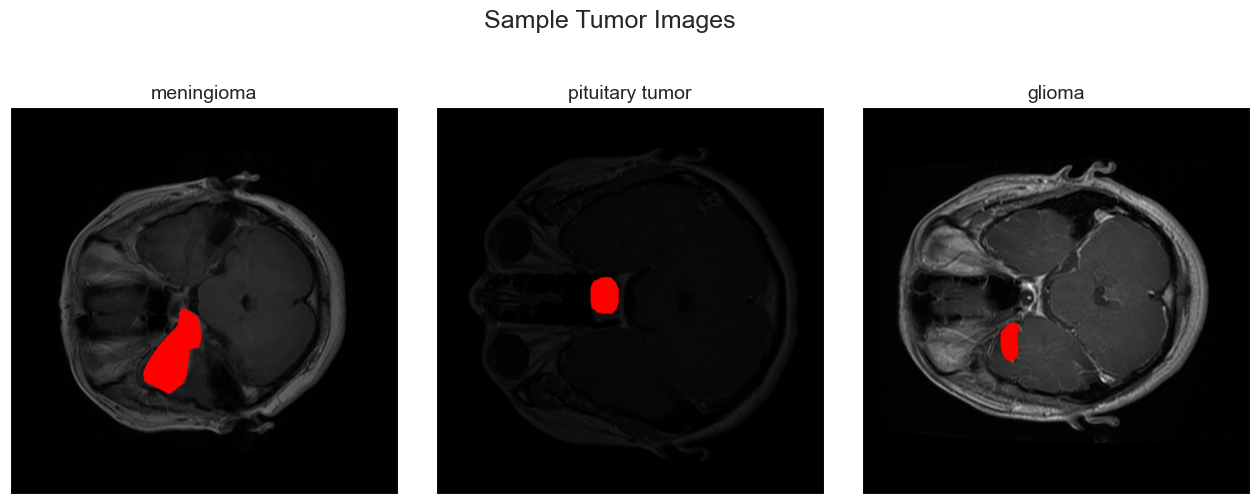

In [9]:
# Create the figure and axes
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))

# Loop over the images
for i in range(3):
    # Plot the image
    ax[i].imshow(tumor[i], cmap='gray')
    
    # Set the title
    ax[i].set_title(names[int(labels[i]-1)], fontsize=14)
    
    # Remove the axis ticks
    ax[i].set_xticks([])
    ax[i].set_yticks([])

# Set the figure title
fig.suptitle('Sample Tumor Images', fontsize=18)

# Adjust the spacing between the subplots
fig.subplots_adjust(wspace=0.1)

# Save the plot as a PNG file
plt.savefig('sample_tumor_images.png')

# Show the plot
plt.show()

This code block a figure that shows sample tumor images from the dataset. Here's a step-by-step explanation of what the code does:

1. `fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(16, 6))` creates a figure with 1 row and 3 columns of subplots using the `subplots` function from the `matplotlib` library, and stores the resulting `Figure` and `AxesSubplot` objects in the `fig` and `ax` variables, respectively.
2. `for i in range(3):` loops over the first 3 images in the `tumor` NumPy array.
3. `ax[i].imshow(tumor[i], cmap='gray')` displays the image in the `i`-th row and column of the subplot using the `imshow` function from the `matplotlib` library, and sets the colormap to grayscale.
4. `ax[i].set_title(names[int(labels[i]-1)], fontsize=14)` sets the title of the subplot to the tumor type corresponding to the `i`-th image using the `names` list and the `labels` NumPy array.
5. `ax[i].set_xticks([])` and `ax[i].set_yticks([])` remove the x and y axis ticks from the subplot.
6. `fig.suptitle('Sample Tumor Images', fontsize=18)` sets the title of the entire figure.
7. `fig.subplots_adjust(wspace=0.1)` adjusts the spacing between the subplots.
8. `plt.savefig('sample_tumor_images.png')` saves the figure as a PNG file.
9. `plt.show()` displays the figure.

## Quantum Convolution Node
    

In [10]:
wires= 4

# Define the simulator device with 4 qubits
dev4 = qml.device("default.qubit", wires=wires) 

# Define the circuit
@qml.qnode(dev4)

def CONV(phi, wires, i=0):
    # Set the parameter theta
    theta = np.pi / 2

    # Apply RX gates to each qubit with the corresponding parameter value
    qml.RX(phi[0] * np.pi, wires=0)
    qml.RX(phi[1] * np.pi, wires=1)
    qml.RX(phi[2] * np.pi, wires=2)
    qml.RX(phi[3] * np.pi, wires=3)

    # Apply CRZ and CRX gates to specific pairs of qubits
    qml.CRZ(theta, wires=[1, 0])
    qml.CRZ(theta, wires=[3, 2])
    qml.CRX(theta, wires=[1, 0])
    qml.CRX(theta, wires=[3, 2])
    qml.CRZ(theta, wires=[2, 0])
    qml.CRX(theta, wires=[2, 0])

    # Measure the expectation value of the PauliZ operator on the first qubit
    measurement = qml.expval(qml.PauliZ(wires=0))

    return measurement

This code defines a quantum circuit using the PennyLane library. The circuit is called `CONV` and takes two arguments: `phi` and `wires`. 

The `phi` argument is a list of four parameters that are used to apply rotations to the qubits. The `wires` argument specifies the number of qubits in the circuit, which is set to 4.

The circuit applies a series of gates to the qubits, including RX, CRZ, and CRX gates. The gates are applied to specific pairs of qubits, as specified by the `wires` argument.

Finally, the circuit measures the expectation value of the PauliZ operator on the first qubit and returns the result.

To use this circuit, you would need to define the `phi` parameter values and call the `CONV` function with those values and the desired number of qubits. The output of the function would be the expectation value of the PauliZ operator on the first qubit.

The `wires` argument specifies the number of qubits in the quantum circuit. In this case, `wires=4` means that the circuit has 4 qubits.

The number of qubits in a quantum circuit determines the size and complexity of the problems that can be solved using the circuit. Generally, larger circuits with more qubits can solve more complex problems, but they also require more resources to run and are more difficult to implement in practice.

In this specific circuit, the number of qubits is set to 4, which means that the circuit can be used to solve problems that require up to 4 qubits. The circuit applies a series of gates to the qubits, including RX, CRZ, and CRX gates, and measures the expectation value of the PauliZ operator on the first qubit. The specific problem that this circuit is designed to solve depends on the values of the `phi` parameter and the input data that is fed into the circuit.

## Quantum Convolutional Layer

In [11]:
def QCONV1(Img, image_number, image_total, step=2):
    
    H, W = Img.shape
    step2 = 2
    out = np.zeros(((H//step), (W//step)))
    
    for i in tqdm(range(0, W, step), desc="Processing image "+str(image_number)+"/"+str(image_total)):
        for j in range(0, H, step):
            # get 2x2 pixels and make them 1D array
            phi = Img[i:i+2, j:j+2].flatten()
            # Get Measurement
            measurement = CONV(phi, len(phi))
            out[i//step, j//step] = measurement

    return out

This function applies a quantum convolutional layer to an input image `Img` using the `CONV` function. The output of the function is a 2D array that represents the result of the convolutional layer.

The function works by iterating over the pixels in the input image in steps of `step` pixels. For each 2x2 block of pixels, the function flattens the block into a 1D array and applies the `CONV` function to it to get a measurement. The measurement is then stored in the output array at the appropriate location.

The `Img` argument is a 2D array representing the input image. The `image_number` and `image_total` arguments are used to display the progress of the function. The `step` argument determines the step size used when iterating over the pixels in the image.

The `H` and `W` variables are the height and width of the input image, respectively. The `step2` variable is not used in the function and can be removed.

The `out` variable is a 2D array that will store the output of the convolutional layer. It is initialized to an array of zeros with dimensions `(H//step, W//step)`.

The `for` loop iterates over the pixels in the input image in steps of `step` pixels. The `tqdm` function is used to create a progress bar that shows the progress of the loop. The `desc` argument is used to set the description of the progress bar, which in this case is "Processing image X/Y", where X is the current image number and Y is the total number of images.

For each 2x2 block of pixels, the function flattens the block into a 1D array and applies the `CONV` function to it to get a measurement. The measurement is then stored in the output array at the appropriate location.

Finally, the function returns the output array.

## Visualizing the Quantum Convolutional Circuit

In [12]:
# Define input phi
phi = [1, 1, 1, 1]

# Create a circuit drawer for the CONV function
drawer = qml.draw(CONV)

# Draw the circuit for phi with 4 qubits
print("Circuit for phi = [1, 1, 1, 1] with 4 qubits:")
print("```")
print(drawer(phi, 4))
print("```")

Circuit for phi = [1, 1, 1, 1] with 4 qubits:
```
0: ──RX(3.14)─╭RZ(1.57)─╭RX(1.57)─╭RZ(1.57)─╭RX(1.57)─┤  <Z>
1: ──RX(3.14)─╰●────────╰●────────│─────────│─────────┤     
2: ──RX(3.14)─╭RZ(1.57)─╭RX(1.57)─╰●────────╰●────────┤     
3: ──RX(3.14)─╰●────────╰●────────────────────────────┤     
```


## Applying the Quantum Convolutional Layer to the Input Images

In [13]:
processFolder = 'Resize/'

# Start a timer to measure the execution time
start = timer()

# Set the width of the images to 512 and the step size to 2
w = 512
step = 2

# Initialize a counter and get a list of all files in the folder
k = 0
directs = sorted(listdir(folder))

# Loop over each file in the folder
for file in directs:
    # Check if the file has already been processed
    all64 = sorted(listdir(processFolder))
    if file+".npz" in all64:
        continue
    
    # Load the image and label from the file
    f = h5py.File(folder+file, 'r')
    img = np.array(f.get("cjdata/image"))
    if img.shape[0] < 512:
        continue
    label = np.array(f.get("cjdata/label"))[0][0]

    # Resize the image to 25% of its original size
    scale_percent = 25
    width = int(img.shape[1] * scale_percent / 100)
    height = int(img.shape[0] * scale_percent / 100)
    dim = (width, height)
    resized = cv2.resize(img, dim, interpolation = cv2.INTER_AREA)
    NorImages = resized/255

    # Apply the QCONV1 function to the image
    processed = QCONV1(NorImages, str(k)+" "+file, (len(directs)-len(all64)), step)

    # Save the processed image and label to a compressed numpy file
    np.savez_compressed(processFolder+file, image=processed, label=label)
    k+=1

# Stop the timer and calculate the execution time
end = timer()
time = (end - start)
execution_time = str(timedelta(seconds=round(time)))

# Format the execution time as "hh:mm:ss"
formatted_time = datetime.strptime(execution_time, '%H:%M:%S').strftime('%H:%M:%S')

# Print the execution time
print("Execution time: " + formatted_time + " 👀")

Processing image 379 1350.mat/2685:  47%|████▋     | 30/64 [00:08<00:12,  2.69it/s]



This code loads images from a folder, resizes them, applies a quantum convolutional layer using the `QCONV1` function, and saves the processed images to a compressed numpy file. The code also measures the execution time of the process.

## Visualizing image after applying quantum convolutional layer

In [ ]:
# Set the directory where the images are stored
directory = "Resize/"

# Get a list of all the files in the directory
files = os.listdir(directory)

# Select 10 random files
random_files = random.sample(files, 10)

# Loop over each random file
for file in random_files:
    # Load the image from the file
    img = np.load(directory + file)['image']
    
    # Plot the image
    plt.imshow(img, "gray")
    plt.show()
    
    # Save the image
    plt.imsave(file + ".png", img, cmap="gray")